# Belajar Lebih Lama, Nilai Lebih Tinggi?
### EDA waktu belajar dan nilai akhir 649 siswa
**Muhammad Fierlyan Irwandi · 3224600051**  
Pengantar Kecerdasan Artifisial dan Pembelajaran Mesin  
Teknik Komputer · Politeknik Elektronika Negeri Surabaya

**Pertanyaan sederhana:** apakah kelompok siswa yang belajar lebih lama juga memiliki rata-rata nilai lebih tinggi?

**Jawaban singkat:** ada kecenderungan tersebut dalam data ini, tetapi tidak naik pada setiap kategori. Kelompok 5–10 jam memiliki rata-rata 66,1; kelompok >10 jam 65,3. Ini perbandingan kelompok, bukan bukti bahwa durasi tertentu menyebabkan nilai tertentu.

Notebook disusun untuk tugas Materi 04: minimal 100 baris, `head`, `shape`, `info`, `describe`, minimal tiga grafik, fitur–target, dan lima insight. Ada **empat grafik**, masing-masing disertai cara membaca dan interpretasi.

## 1. Data yang digunakan

Sumber: **Student Performance** oleh Paulo Cortez, UCI Machine Learning Repository, DOI [10.24432/C5TG7T](https://doi.org/10.24432/C5TG7T), lisensi CC BY 4.0. Data dihimpun melalui laporan sekolah dan kuesioner dari dua sekolah menengah di Portugal. Kita memakai **student-por.csv**, mata pelajaran Bahasa Portugis, sebanyak 649 baris; setiap baris mewakili satu catatan siswa dalam mata pelajaran tersebut.

Dataset ini dirujuk pada publikasi **2008** dan diunduh pada **18 September 2026**. Tanggal unduh bukan tahun pengumpulan data. Ini data historis, bukan survei siswa Indonesia atau kondisi pendidikan terkini.

File matematika tidak digabung karena sebagian siswa terdapat pada kedua mata pelajaran. Data mentah 33 kolom tetap disimpan; analisis memakai enam kolom agar fokus.

**Cara memahami variabel:**
- `waktu_belajar`: kategori waktu belajar per minggu, sesuai label UCI; bukan jam persis atau durasi hasil pengukuran.
- `nilai_periode1`, `nilai_periode2`, `nilai_akhir`: nilai asli G1, G2, G3 pada skala 0–20, dikali 5 agar tampil pada skala **0–100**. Contoh: 12 menjadi 60. Ini hanya penskalaan, bukan konversi standar kelulusan Indonesia.
- `sekolah`: kode GP atau MS; `absensi`: jumlah ketidakhadiran menurut sumber. Keduanya disimpan sebagai konteks.

Label 2–5 dan 5–10 jam mengikuti kategori sumber; batas tepat 5 jam tidak diperbaiki sendiri karena jam individual tidak tersedia.

In [1]:
from pathlib import Path
import hashlib
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'data/raw/student-por.csv').exists():
    raise FileNotFoundError('Buka notebook dari folder utama repositori.')
sys.path.insert(0, str(ROOT / 'src'))
from prepare_data import LABELS, prepare

raw_path = ROOT / 'data/raw/student-por.csv'
provenance = json.loads((ROOT / 'data/provenance.json').read_text())
assert hashlib.sha256(raw_path.read_bytes()).hexdigest() == provenance['raw_sha256']
raw = pd.read_csv(raw_path, sep=';')
df = prepare(raw)
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'figure.dpi': 120,
                     'savefig.dpi': 180, 'axes.labelcolor': '#253449',
                     'text.color': '#253449', 'axes.edgecolor': '#b5bdc8'})
BLUE, TEAL, GRAY = '#315f85', '#168278', '#abb8c6'
def simpan(fig, nama):
    fig.text(.07, .015, 'Sumber: UCI Student Performance (Cortez, 2008) • Bahasa Portugis • n = 649',
             fontsize=8, color='#64748b')
    fig.tight_layout(rect=[0, .06, 1, 1])
    fig.savefig(FIG / nama, facecolor='white', bbox_inches='tight')
    plt.show()
    plt.close(fig)

print('Data mentah:', raw.shape, '| Data analisis:', df.shape)

Matplotlib is building the font cache; this may take a moment.


Data mentah: (649, 33) | Data analisis: (649, 6)


## 2. Pemeriksaan awal: head, shape, info, describe
Lima baris pertama membantu mengenali isi kolom. Ukuran tabel menunjukkan jumlah siswa dan variabel. `info()` memeriksa tipe data dan nilai kosong; `describe()` merangkum angka serta kategori.

In [2]:
display(df.head())
print('shape:', df.shape)
df.info()
display(df.describe(include='all'))

,sekolah,waktu_belajar,absensi,nilai_periode1,nilai_periode2,nilai_akhir
0,GP,2–5 jam,4,0,55,55
1,GP,2–5 jam,2,45,55,55
2,GP,2–5 jam,6,60,65,60
3,GP,5–10 jam,0,70,70,70
4,GP,2–5 jam,0,55,65,65


shape: (649, 6)
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sekolah         649 non-null    str     
 1   waktu_belajar   649 non-null    category
 2   absensi         649 non-null    int64   
 3   nilai_periode1  649 non-null    int64   
 4   nilai_periode2  649 non-null    int64   
 5   nilai_akhir     649 non-null    int64   
dtypes: category(1), int64(4), str(1)
memory usage: 26.3 KB


,sekolah,waktu_belajar,absensi,nilai_periode1,nilai_periode2,nilai_akhir
count,649,649,649.000000,649.000000,649.000000,649.000000
unique,2,4,NaN,NaN,NaN,NaN
top,GP,2–5 jam,NaN,NaN,NaN,NaN
freq,423,305,NaN,NaN,NaN,NaN
mean,NaN,NaN,3.659476,56.995378,57.850539,59.530046
std,NaN,NaN,4.640759,13.726326,14.568193,16.153281
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,0.000000,50.000000,50.000000,50.000000
50%,NaN,NaN,2.000000,55.000000,55.000000,60.000000
75%,NaN,NaN,6.000000,65.000000,65.000000,70.000000


**Interpretasi:** tabel analisis berisi 649 baris dan enam kolom. Nilai akhir memiliki rata-rata 59,53, median 60, dan rentang teramati 0–95 pada skala 0–100. Angka 100 tetap menjadi batas skala walaupun tidak muncul pada sampel. `NaN` pada tabel `describe(include='all')` berarti statistik itu tidak berlaku untuk jenis kolom tersebut, bukan otomatis data hilang.

In [3]:
cek = pd.DataFrame({'nilai_kosong': df.isna().sum(), 'jumlah_nilai_unik': df.nunique()})
display(cek)
print('Duplikat identik pada 33 kolom sumber:', int(raw.duplicated().sum()))
print('Baris identik pada enam kolom terpilih:', int(df.duplicated().sum()))
print('Jumlah nilai akhir nol:', int(df.nilai_akhir.eq(0).sum()))
assert len(df) >= 100 and df.isna().sum().sum() == 0
assert df[['nilai_periode1', 'nilai_periode2', 'nilai_akhir']].ge(0).all().all()
assert df[['nilai_periode1', 'nilai_periode2', 'nilai_akhir']].le(100).all().all()

,nilai_kosong,jumlah_nilai_unik
sekolah,0,2
waktu_belajar,0,4
absensi,0,24
nilai_periode1,0,17
nilai_periode2,0,16
nilai_akhir,0,17


Duplikat identik pada 33 kolom sumber: 0
Baris identik pada enam kolom terpilih: 78
Jumlah nilai akhir nol: 15


Tidak ada nilai kosong atau duplikat identik pada data mentah. Kesamaan enam kolom terpilih tidak membuktikan dua baris adalah siswa yang sama, sehingga tidak dihapus. Sebanyak **15 nilai akhir nol** tetap dipertahankan: nol berada dalam rentang sah sumber, dan alasannya tidak diketahui. Tidak ada imputasi atau pembuangan outlier. Dengan demikian, semua 649 baris masuk analisis utama.

## 3. Grafik 1 — Seperti apa sebaran nilai akhir?
Sumbu horizontal adalah nilai akhir; tinggi batang menunjukkan banyaknya siswa pada rentang tersebut. Garis putus-putus menunjukkan median: setengah pengamatan berada di bawah atau sama dengan nilai tengah ini.

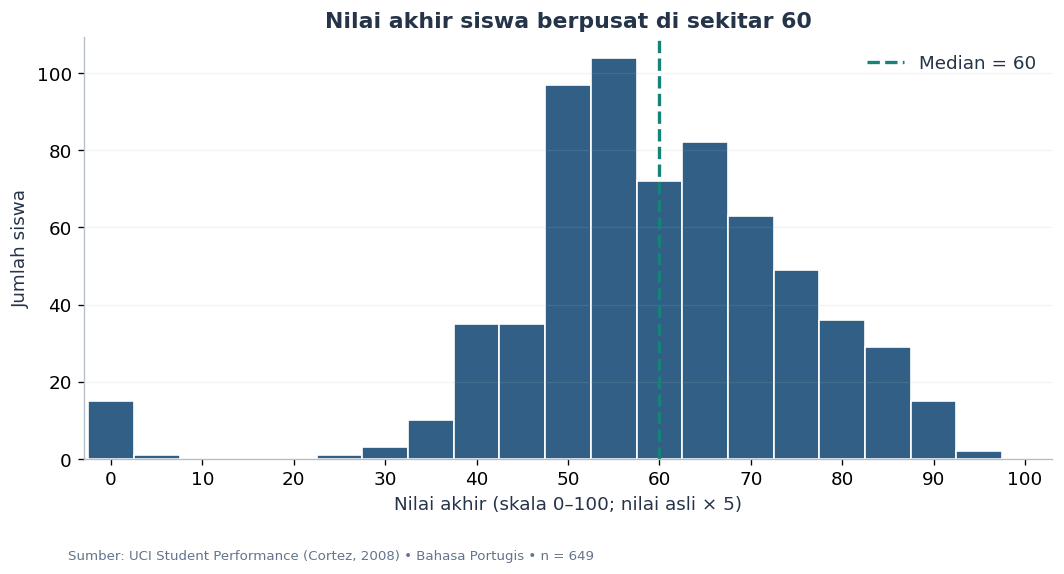

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(df.nilai_akhir, bins=np.arange(-2.5, 103, 5), color=BLUE, edgecolor='white')
ax.axvline(df.nilai_akhir.median(), color=TEAL, ls='--', lw=2, label='Median = 60')
ax.set(title='Nilai akhir siswa berpusat di sekitar 60',
       xlabel='Nilai akhir (skala 0–100; nilai asli × 5)', ylabel='Jumlah siswa',
       xlim=(-3, 103), xticks=range(0, 101, 10))
ax.legend(frameon=False)
ax.grid(axis='y', alpha=.15)
simpan(fig, '01_distribusi_nilai.png')

**Interpretasi:** rata-rata 59,53 dekat dengan median 60. Kuartil bawah 50 dan kuartil atas 70 menunjukkan rentang tengah pengamatan. Sebagian nilai berada jauh lebih rendah, termasuk nol. Grafik ini mendeskripsikan nilai dalam sampel, bukan menentukan siapa yang lulus berdasarkan aturan Indonesia.

## 4. Grafik 2 — Berapa siswa dalam setiap kelompok belajar?
Sebelum membandingkan nilai, periksa jumlah anggota kelompok. Rata-rata dari kelompok kecil lebih mudah berubah bila beberapa siswa ditambah atau dikeluarkan.

,jumlah_siswa,rata_rata,median,minimum,maksimum,persen_siswa
waktu_belajar,,,,,,
<2 jam,212,54.22,55.0,0,90,32.67
2–5 jam,305,60.46,60.0,0,95,47.00
5–10 jam,97,66.13,65.0,40,90,14.95
>10 jam,35,65.29,65.0,30,95,5.39


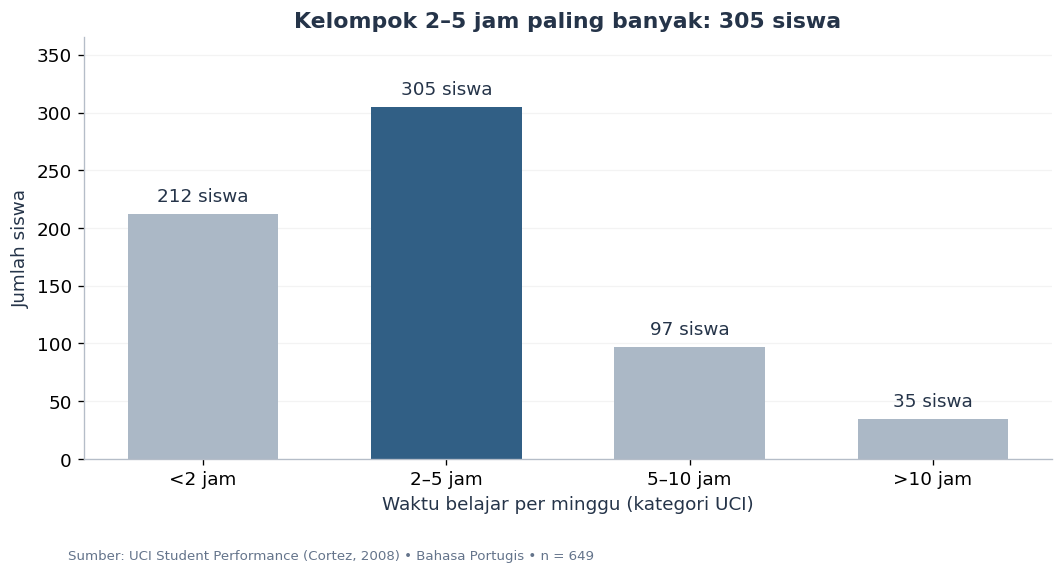

In [5]:
ringkasan = df.groupby('waktu_belajar', observed=False)['nilai_akhir'].agg(
    jumlah_siswa='size', rata_rata='mean', median='median', minimum='min', maksimum='max')
ringkasan['persen_siswa'] = ringkasan.jumlah_siswa / len(df) * 100
display(ringkasan.round(2))
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar(LABELS, ringkasan.jumlah_siswa, color=[GRAY, BLUE, GRAY, GRAY], width=.62)
ax.bar_label(bars, labels=[f'{n} siswa' for n in ringkasan.jumlah_siswa], padding=5)
ax.set(title='Kelompok 2–5 jam paling banyak: 305 siswa', xlabel='Waktu belajar per minggu (kategori UCI)',
       ylabel='Jumlah siswa', ylim=(0, 365))
ax.grid(axis='y', alpha=.15)
ax.set_axisbelow(True)
simpan(fig, '02_jumlah_kelompok.png')

**Interpretasi:** 305 siswa (47,0%) berada pada kategori 2–5 jam; kelompok >10 jam hanya 35 siswa (5,4%). Jadi, empat rata-rata berikut tidak memiliki ukuran kelompok yang sama. Kita tidak menafsirkan kelompok kecil sebagai standar bagi semua siswa.

## 5. Grafik 3 — Belajar lebih lama, nilai lebih tinggi?
Ini grafik utama presentasi. Tinggi batang adalah **rata-rata nilai akhir**, bukan jumlah siswa. Semua batang dimulai dari nol agar selisih tidak tampak berlebihan. `n` menyatakan jumlah siswa pada kelompok.

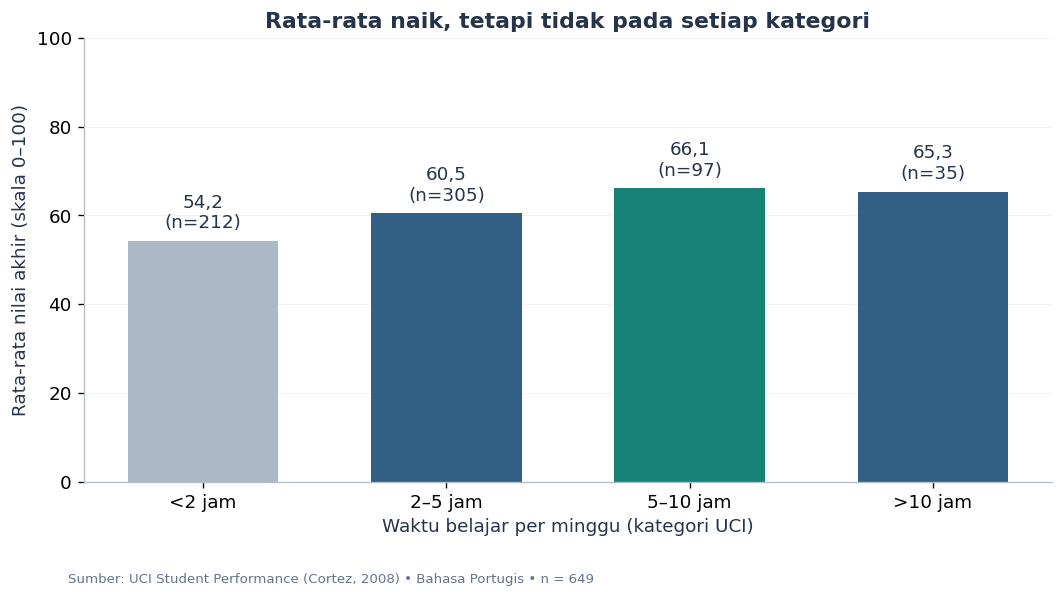

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(LABELS, ringkasan.rata_rata, color=[GRAY, BLUE, TEAL, BLUE], width=.62)
for b, (_, row) in zip(bars, ringkasan.iterrows()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+2,
            f"{row.rata_rata:.1f}".replace('.', ',') + f"\n(n={int(row.jumlah_siswa)})",
            ha='center', va='bottom', fontsize=11)
ax.set(title='Rata-rata naik, tetapi tidak pada setiap kategori',
       xlabel='Waktu belajar per minggu (kategori UCI)', ylabel='Rata-rata nilai akhir (skala 0–100)',
       ylim=(0, 100), yticks=range(0, 101, 20))
ax.grid(axis='y', alpha=.15)
ax.set_axisbelow(True)
simpan(fig, '03_belajar_dan_nilai.png')

**Interpretasi:** rata-rata empat kelompok berturut-turut adalah **54,2; 60,5; 66,1; dan 65,3**. Selisih kelompok 5–10 jam dengan <2 jam adalah **11,9 poin**, bukan 11,9 persen. Kelompok >10 jam tidak memiliki rata-rata tertinggi; selisihnya dengan 5–10 jam hanya **0,8 poin**.

Ini **tidak membuktikan 5–10 jam adalah waktu optimal**, >10 jam merugikan, atau setiap siswa akan mendapat tambahan 11,9 poin dengan memperpanjang waktu belajar. Kemampuan awal, sekolah, dukungan belajar, dan faktor lain bisa berbeda. Kita hanya membandingkan kelompok yang sudah ada, tanpa eksperimen atau penyesuaian faktor tersebut.

## 6. Grafik 4 — Nilai sebelumnya dan nilai akhir
Setiap titik menampilkan nilai periode kedua dan nilai akhir. Beberapa siswa memiliki pasangan nilai identik; **ukuran titik** menunjukkan banyaknya siswa pada pasangan itu. Garis diagonal menunjukkan nilai akhir sama dengan periode kedua; ini bukan garis model prediksi.

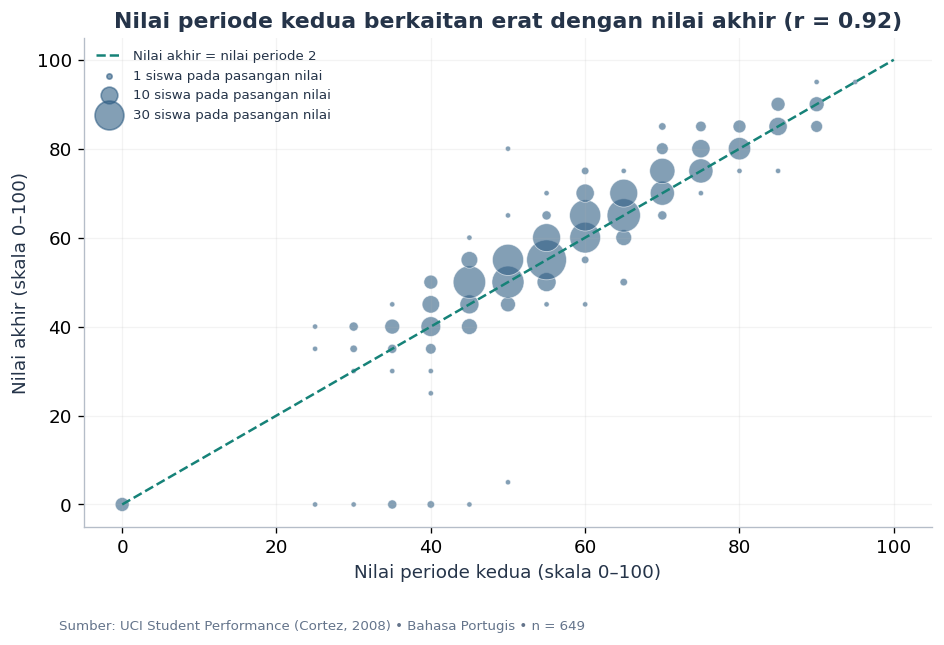

In [7]:
pasangan = df.groupby(['nilai_periode2', 'nilai_akhir']).size().reset_index(name='n')
r = df.nilai_periode2.corr(df.nilai_akhir)
fig, ax = plt.subplots(figsize=(8, 5.4))
ax.scatter(pasangan.nilai_periode2, pasangan.nilai_akhir, s=pasangan.n * 10,
           alpha=.6, color=BLUE, edgecolors='white', linewidths=.5)
ax.plot([0, 100], [0, 100], ls='--', color=TEAL, lw=1.5, label='Nilai akhir = nilai periode 2')
for n in [1, 10, 30]:
    ax.scatter([], [], s=n*10, alpha=.6, color=BLUE, label=f'{n} siswa pada pasangan nilai')
ax.set(title=f'Nilai periode kedua berkaitan erat dengan nilai akhir (r = {r:.2f})',
       xlabel='Nilai periode kedua (skala 0–100)', ylabel='Nilai akhir (skala 0–100)',
       xlim=(-5, 105), ylim=(-5, 105))
ax.legend(frameon=False, loc='upper left', fontsize=8)
ax.grid(alpha=.15)
simpan(fig, '04_nilai_sebelumnya.png')

**Interpretasi:** korelasi Pearson sekitar **0,92** berarti siswa dengan nilai periode kedua lebih tinggi cenderung memiliki nilai akhir lebih tinggi. Angka 0,92 bukan akurasi 92% dan bukan bukti sebab-akibat. Kedua nilai berasal dari rangkaian penilaian mata pelajaran yang sama. Karena nilai periode kedua belum tersedia pada awal tahun, manfaatnya bergantung pada kapan prediksi ingin dibuat.

## 7. Pemeriksaan tambahan untuk pembaca riset
Bagian ini tidak perlu dipresentasikan. Kita memeriksa apakah pola utama hanya muncul karena dua sekolah dicampur, serta apa yang terjadi jika nilai nol dikeluarkan sebagai skenario pembanding. Analisis utama tetap memakai seluruh data.

In [8]:
per_sekolah = df.groupby(['sekolah', 'waktu_belajar'], observed=False).nilai_akhir.agg(['size', 'mean'])
tanpa_nol = df[df.nilai_akhir > 0].groupby('waktu_belajar', observed=False).nilai_akhir.agg(['size', 'mean'])
display(per_sekolah.round(2))
display(tanpa_nol.round(2).rename(columns={'size':'n_tanpa_nol', 'mean':'rata_rata_tanpa_nol'}))

size   mean
sekolah waktu_belajar             
GP      <2 jam          119  57.65
        2–5 jam         206  63.67
        5–10 jam         71  67.82
        >10 jam          27  67.04
MS      <2 jam           93  49.84
        2–5 jam          99  53.79
        5–10 jam         26  61.54
        >10 jam           8  59.38

,n_tanpa_nol,rata_rata_tanpa_nol
waktu_belajar,,
<2 jam,204,56.35
2–5 jam,298,61.88
5–10 jam,97,66.13
>10 jam,35,65.29


Pada kedua sekolah, rata-rata kategori 5–10 jam tetap di atas <2 jam. Setelah 15 nilai nol dikeluarkan, rata-rata kategori <2 jam menjadi 56,3 dan 5–10 jam tetap 66,1. Pola deskriptif bertahan, tetapi ini belum mengendalikan semua faktor pembeda dan bukan uji kausal. Nilai nol tidak dihapus dari analisis utama hanya karena hasil menjadi lebih menarik.

## 8. Fitur (X) dan target (y)

Contoh tujuan ML: **memperkirakan nilai akhir setelah nilai periode kedua tersedia**.
- **Fitur X:** waktu belajar, nilai periode pertama, dan nilai periode kedua.
- **Target y:** nilai akhir. Karena berbentuk angka, tugas ini dapat dirumuskan sebagai regresi.
- Waktu belajar perlu diubah dari kategori menjadi representasi numerik, misalnya one-hot encoding. Kode kategori tidak boleh dianggap jam pasti.
- `absensi` tidak dipakai sebagai fitur dalam contoh ini karena waktu rekapnya tidak jelas; memasukkan informasi yang baru tersedia setelah waktu prediksi berisiko membocorkan informasi masa depan.
- Jika prediksi dibuat pada awal tahun, G1 dan G2 belum tersedia dan harus dikeluarkan. Data kuesioner juga perlu dipastikan tersedia sebelum waktu prediksi.

Notebook ini **tidak melatih model**: fokus tugas adalah memahami data. Identifikasi X dan y bukan klaim bahwa model sudah layak dipakai. Pada pengembangan lanjut, tetapkan waktu prediksi, pisahkan data latih/uji sebelum mempelajari transformasi, dan bandingkan dengan prediksi sederhana menggunakan rata-rata data latih.

In [9]:
fitur = ['waktu_belajar', 'nilai_periode1', 'nilai_periode2']
target = 'nilai_akhir'
X, y = df[fitur].copy(), df[target].copy()
assert target not in X.columns
print('Bentuk fitur X:', X.shape, '| Bentuk target y:', y.shape)
display(X.head())
display(y.head())

Bentuk fitur X: (649, 3) | Bentuk target y: (649,)


,waktu_belajar,nilai_periode1,nilai_periode2
0,2–5 jam,0,55
1,2–5 jam,45,55
2,2–5 jam,60,65
3,5–10 jam,70,70
4,2–5 jam,55,65


0    55
1    55
2    60
3    70
4    65
Name: nilai_akhir, dtype: int64

## 9. Lima insight EDA
1. **Sebanyak 305 dari 649 siswa (47,0%) belajar 2–5 jam per minggu**, sehingga kategori ini paling banyak terwakili.
2. **Rata-rata nilai akhir adalah 59,5 dan median 60** pada skala tampilan 0–100.
3. **Kelompok 5–10 jam memiliki rata-rata 66,1, dibanding 54,2 pada <2 jam**, selisih deskriptif 11,9 poin.
4. **Kelompok >10 jam memiliki rata-rata 65,3 dan hanya 35 siswa**; durasi paling panjang tidak menghasilkan rata-rata tertinggi pada sampel ini.
5. **Nilai periode kedua dan nilai akhir berkorelasi sekitar 0,92**, tetapi nilai sebelumnya hanya boleh menjadi fitur jika sudah tersedia saat prediksi.

## 10. Kesimpulan dan batasan
**Jawaban penelitian:** kelompok belajar lebih lama cenderung memiliki rata-rata nilai lebih tinggi, tetapi pola tidak terus naik dan durasi bukan jaminan nilai individu. EDA membantu melihat pola serta pertanyaan yang masih perlu dijawab.

Batas kajian: data historis dari dua sekolah dan satu mata pelajaran; waktu belajar berupa kategori kuesioner; jumlah siswa tiap kelompok berbeda; tidak ada eksperimen, pengendalian semua faktor pembeda, atau klaim generalisasi ke Indonesia. Kajian ini tidak menetapkan jumlah jam belajar ideal. Perbedaan 0,8 poin antar dua kategori teratas tidak diuji signifikansinya dan tidak diperlakukan sebagai bukti keunggulan.

## Referensi dan reproduksi
1. Cortez, P. (2008). *Student Performance* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5TG7T. Diakses 18 September 2026. Lisensi CC BY 4.0.
2. Cortez, P., & Silva, A. M. G. (2008). *Using Data Mining to Predict Secondary School Student Performance*. Studi pengantar yang ditautkan pada [halaman dataset UCI](https://archive.ics.uci.edu/dataset/320/student+performance).
3. Sigit, R. *Materi 04: Python dan Data Exploration untuk Machine Learning*, instruksi tugas slide 22.

Untuk menjalankan ulang: pasang `requirements.txt`, lalu jalankan `python src/prepare_data.py` dan `python jalankan_ulang.py` dari folder repositori. Semua data tersedia lokal; notebook tidak memerlukan koneksi internet. Rincian kolom dan perubahan tersedia di `docs/KAMUS_DATA.md` dan `data/provenance.json`.

In [10]:
hasil = {
    'jumlah_siswa': len(df), 'kolom_analisis': df.shape[1],
    'mean_nilai_akhir': float(df.nilai_akhir.mean()),
    'median_nilai_akhir': float(df.nilai_akhir.median()),
    'nilai_nol': int(df.nilai_akhir.eq(0).sum()),
    'r_periode2_akhir': float(r),
    'selisih_5_10_dengan_kurang2': float(ringkasan.loc['5–10 jam', 'rata_rata'] - ringkasan.loc['<2 jam', 'rata_rata']),
    'kelompok': ringkasan.reset_index().to_dict(orient='records'),
}
(ROOT/'data/processed/hasil_ringkas.json').write_text(json.dumps(hasil, indent=2, ensure_ascii=False)+'\n')
ringkasan.to_csv(ROOT/'data/processed/ringkasan_kelompok.csv')
per_sekolah.to_csv(ROOT/'data/processed/ringkasan_per_sekolah.csv')
tanpa_nol.to_csv(ROOT/'data/processed/sensitivitas_tanpa_nol.csv')
print('Ringkasan, empat grafik, dan pemeriksaan tambahan tersimpan.')

Ringkasan, empat grafik, dan pemeriksaan tambahan tersimpan.
